In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_excel("Air_BNB.xlsx")

In [4]:
data.head()

,id,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
0,6901257,Entire home/apt,3,1.0,strict,True,f,100.0,1.0,1.0,5.010635
1,6304928,Entire home/apt,7,1.0,strict,True,t,93.0,3.0,3.0,5.129899
2,7919400,Entire home/apt,5,1.0,moderate,True,t,92.0,1.0,3.0,4.976734
3,13418779,Entire home/apt,4,1.0,flexible,True,f,NaN,2.0,2.0,6.620073
4,3808709,Entire home/apt,2,1.0,moderate,True,t,40.0,0.0,1.0,4.744932


In [5]:
data.drop('id',axis=1,inplace=True)

In [6]:
data.head()

,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
0,Entire home/apt,3,1.0,strict,True,f,100.0,1.0,1.0,5.010635
1,Entire home/apt,7,1.0,strict,True,t,93.0,3.0,3.0,5.129899
2,Entire home/apt,5,1.0,moderate,True,t,92.0,1.0,3.0,4.976734
3,Entire home/apt,4,1.0,flexible,True,f,NaN,2.0,2.0,6.620073
4,Entire home/apt,2,1.0,moderate,True,t,40.0,0.0,1.0,4.744932


In [7]:
data.isnull().sum()

,0
room_type,0
accommodates,0
bathrooms,200
cancellation_policy,0
cleaning_fee,0
instant_bookable,0
review_scores_rating,16722
bedrooms,91
beds,131
log_price,0


In [8]:
data.shape

(74111, 10)

In [9]:
data.isnull().sum()/data.shape[0]*100

,0
room_type,0.000000
accommodates,0.000000
bathrooms,0.269865
cancellation_policy,0.000000
cleaning_fee,0.000000
instant_bookable,0.000000
review_scores_rating,22.563452
bedrooms,0.122789
beds,0.176762
log_price,0.000000


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   room_type             74111 non-null  object 
 1   accommodates          74111 non-null  int64  
 2   bathrooms             73911 non-null  float64
 3   cancellation_policy   74111 non-null  object 
 4   cleaning_fee          74111 non-null  bool   
 5   instant_bookable      74111 non-null  object 
 6   review_scores_rating  57389 non-null  float64
 7   bedrooms              74020 non-null  float64
 8   beds                  73980 non-null  float64
 9   log_price             74111 non-null  float64
dtypes: bool(1), float64(5), int64(1), object(3)
memory usage: 5.2+ MB


In [11]:
data.columns

Index(['room_type', 'accommodates', 'bathrooms', 'cancellation_policy',
       'cleaning_fee', 'instant_bookable', 'review_scores_rating', 'bedrooms',
       'beds', 'log_price'],
      dtype='object')

In [13]:
cat=[]
bl=[]
num=[]
for column in data.columns:
  if data[column].dtype=='object':
    cat.append(column)
  elif data[column].dtype=='bool':
    bl.append(column)
  else:
    num.append(column)

In [14]:
cat

['room_type', 'cancellation_policy', 'instant_bookable']

In [15]:
bl

['cleaning_fee']

In [16]:
num

['accommodates',
 'bathrooms',
 'review_scores_rating',
 'bedrooms',
 'beds',
 'log_price']

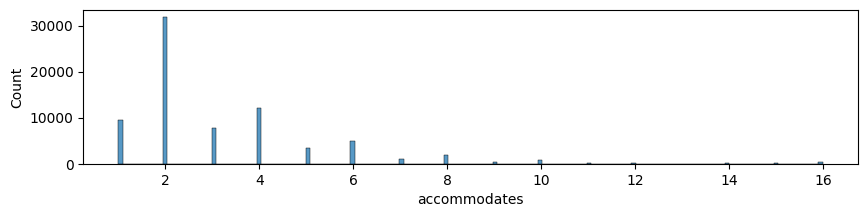

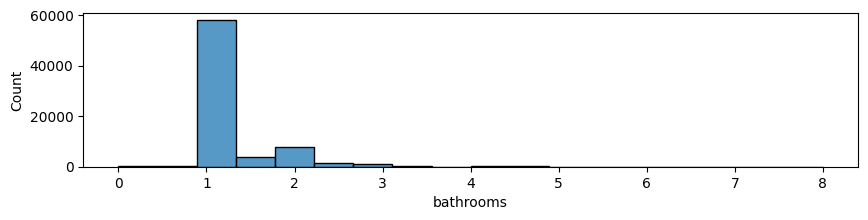

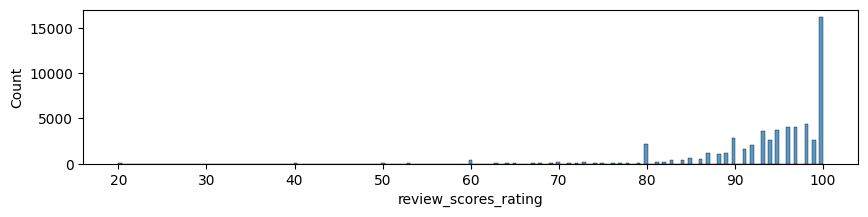

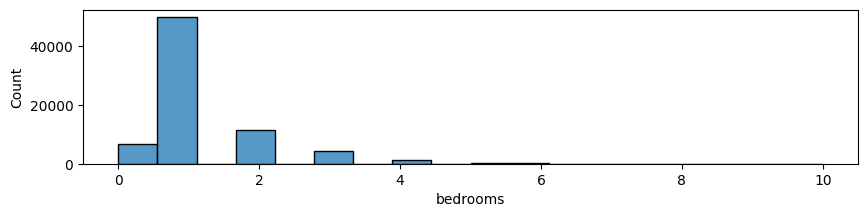

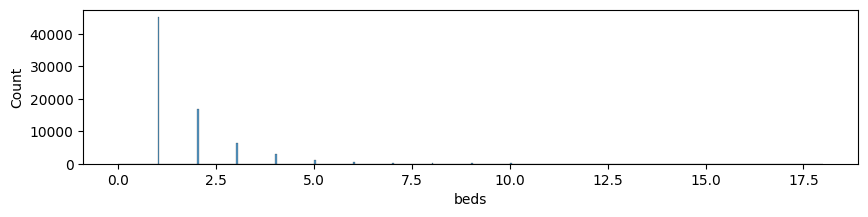

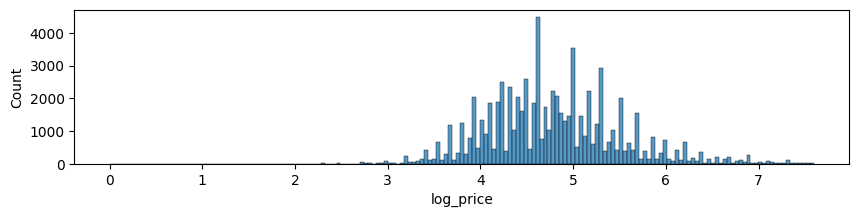

In [17]:
for i in num:
  plt.figure(figsize=(10,2))
  sns.histplot(data[i])

In [18]:
data[num].isnull().sum()

,0
accommodates,0
bathrooms,200
review_scores_rating,16722
bedrooms,91
beds,131
log_price,0


In [19]:
for i in num:
  median = data[i].median()
  data[i]=data[i].fillna(median)

In [20]:
data[num].isnull().sum()

,0
accommodates,0
bathrooms,0
review_scores_rating,0
bedrooms,0
beds,0
log_price,0


In [21]:
for i in cat:
  mode = data[i].mode()[0]
  print(mode)

Entire home/apt
strict
f


In [22]:
for i in cat:
  mode = data[i].mode()[0]
  data[i]=data[i].fillna(mode)

In [23]:
data[cat].isnull().sum()

,0
room_type,0
cancellation_policy,0
instant_bookable,0


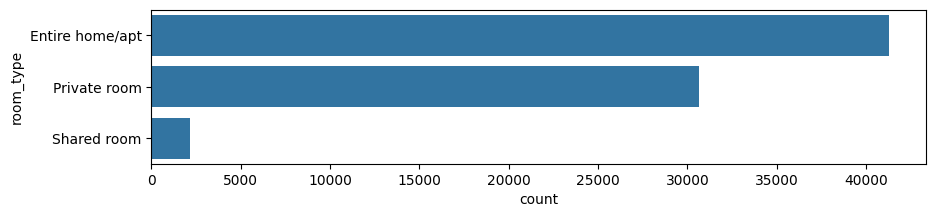

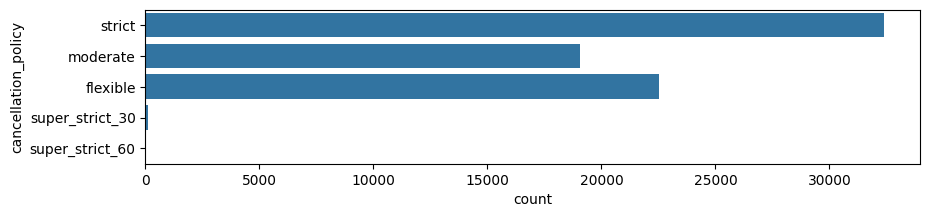

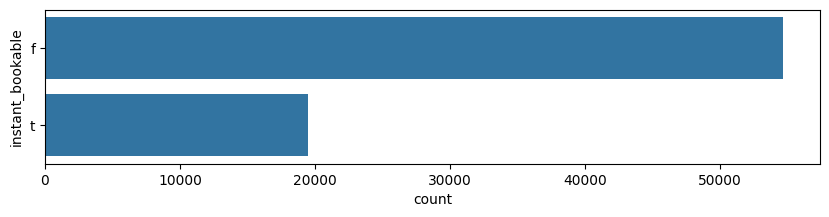

In [24]:
for i in cat:
  plt.figure(figsize=(10,2))
  sns.countplot(data[i])